# Dermatology Dataset — Multi-Class Classification

## Problem Statement

In this work I tackle the problem of classifying six types of erythemato-squamous skin
diseases: psoriasis, seborrheic dermatitis, lichen planus, pityriasis rosea, chronic
dermatitis, and pityriasis rubra pilaris. These conditions look very similar clinically —
they all present with erythema and scaling — so telling them apart from symptoms alone is
difficult. The dataset I'm using has **366 patients** described by **34 features** (12 clinical
and 22 histopathological) and a class label from 1 to 6.

My plan is to try several classifiers — **SVM with linear and RBF kernels** and
**Random Forest** — tune their hyperparameters with GridSearchCV, and compare them using
accuracy and confusion matrices. I will also apply **PCA** to see whether reducing
dimensionality helps or hurts. At the end I'll compare my results with what's been
reported in the literature.

**Dataset source:** [Kaggle — Dermatology Dataset](https://www.kaggle.com/datasets/olcaybolat1/dermatology-dataset-classification/data) (originally from the UCI ML Repository)

---
## 1. Data Loading & Preprocessing

In [15]:
import kagglehub

path = kagglehub.dataset_download("olcaybolat1/dermatology-dataset-classification")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\averb\.cache\kagglehub\datasets\olcaybolat1\dermatology-dataset-classification\versions\5


In [16]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

In [17]:
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))
print(f"Shape: {df.shape}")
df.head()

Shape: (366, 35)


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [18]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")
missing_age_count = df["age"].isna().sum()
print(f"Missing values in 'age': {missing_age_count}")

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df = df_imputed
df["class"] = df["class"].astype(int)

assert df.isnull().sum().sum() == 0
print("Missing values imputed via KNNImputer (k=5).")

Missing values in 'age': 8
Missing values imputed via KNNImputer (k=5).


In [19]:
X = df.drop(columns=["class"])
y = df["class"]

CLASS_NAMES = [
    "1: Psoriasis",
    "2: Seborrheic Derm.",
    "3: Lichen Planus",
    "4: Pityriasis Rosea",
    "5: Chronic Derm.",
    "6: Pityriasis Rubra P.",
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

Train: 292 samples, Test: 74 samples
Features: 34


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized (mean ≈ 0, std ≈ 1).")

Features standardized (mean ≈ 0, std ≈ 1).


---
## 2. Exploratory Data Analysis

Before training any models, let me take a quick look at the class distribution and feature correlations.

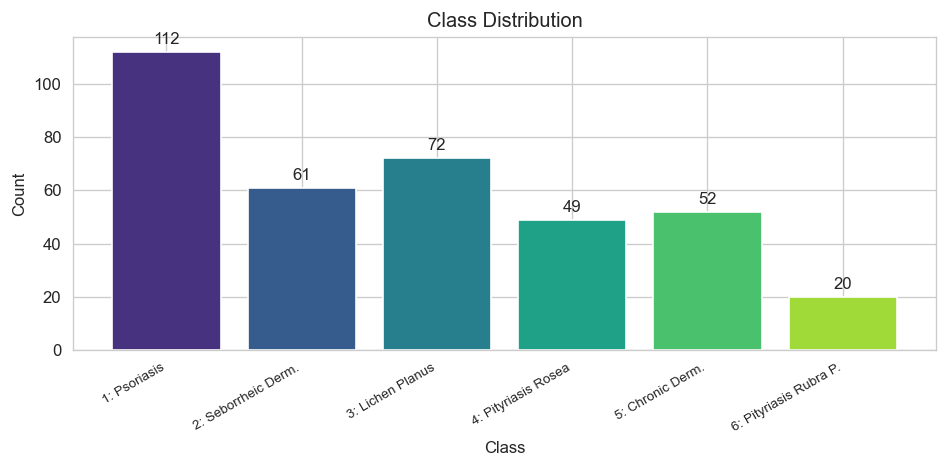

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = y.value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette("viridis", 6))
ax.bar_label(bars, padding=3)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Class Distribution")
ax.set_xticks(range(6))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

The dataset is moderately imbalanced — class 6 (Pityriasis Rubra Pilaris) has only 20 samples.

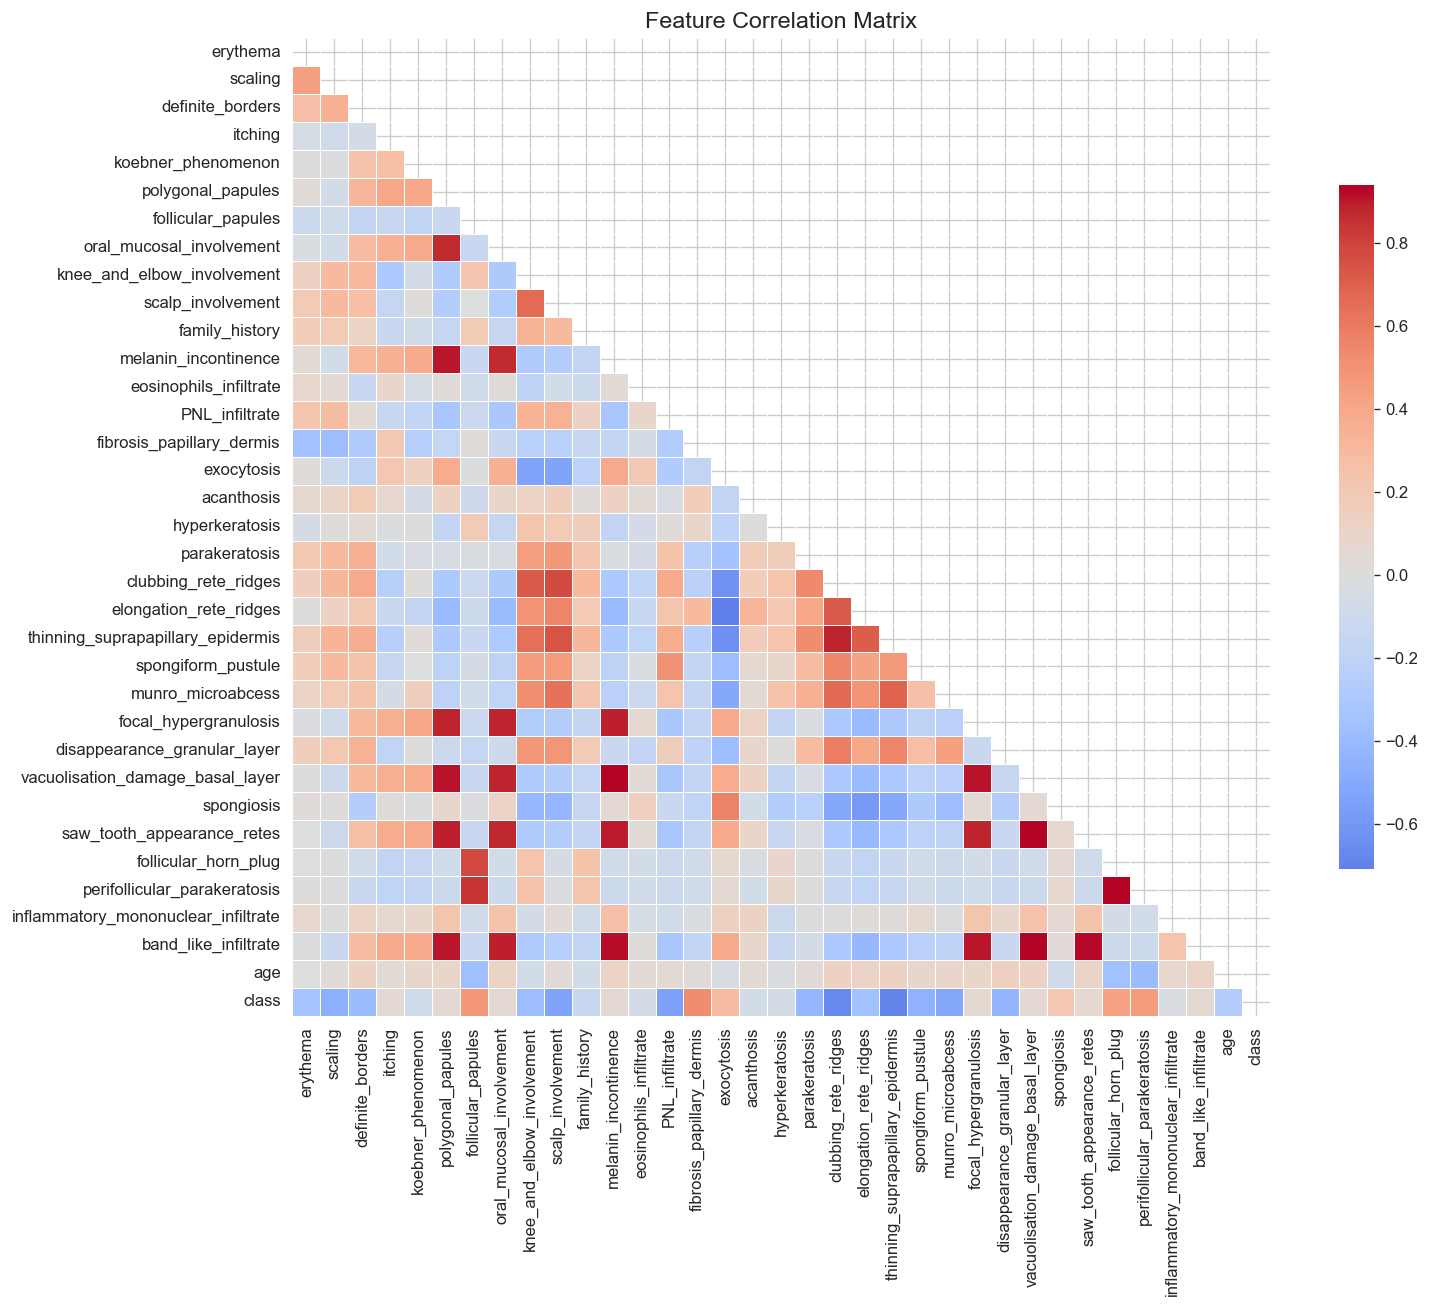

In [22]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap="coolwarm", center=0,
    square=True, linewidths=0.3, ax=ax,
    cbar_kws={"shrink": 0.7},
    annot=False,
)
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering — PCA

PCA (Principal Component Analysis) is an unsupervised technique that projects data onto
orthogonal axes ordered by how much variance they explain. The idea is that if most of the
variance is captured by the first few components, I can drop the rest and work with a
lower-dimensional representation. This can sometimes help by removing noise, although it
can also throw away useful information. I'll try it and see what happens.

I fit PCA on the training set only (to avoid data leakage) and then transform both sets.

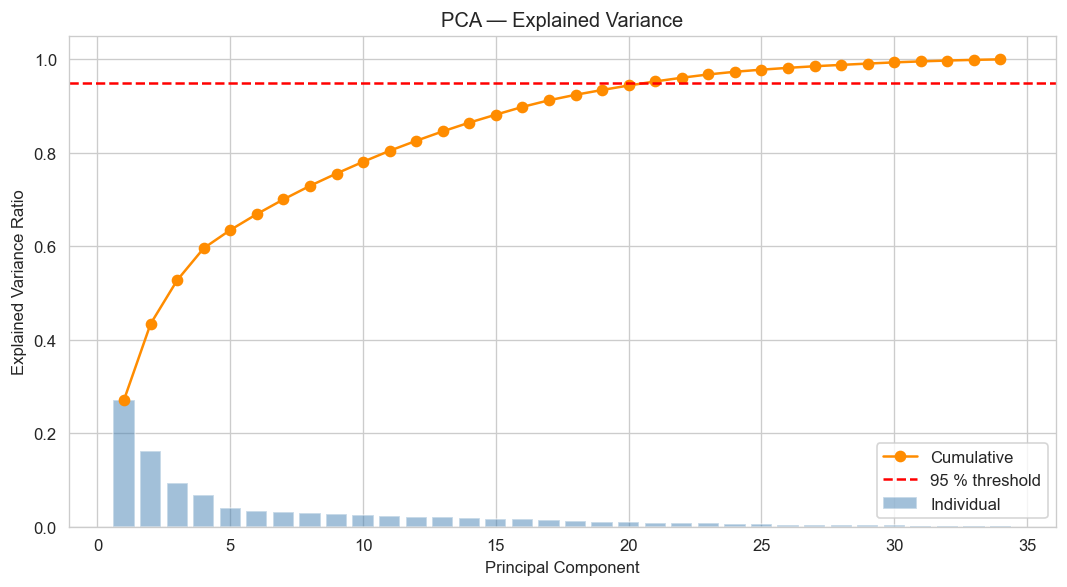

Components needed for ≥ 95% variance: 21 (out of 34)


In [23]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    alpha=0.5, label="Individual", color="steelblue",
)
ax.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance, "o-", color="darkorange",
    label="Cumulative",
)
ax.axhline(y=0.95, color="red", linestyle="--", label="95 % threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA — Explained Variance")
ax.legend()
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)
print(f"Components needed for ≥ 95% variance: {n_components_95} (out of {X_train_scaled.shape[1]})")

In [24]:
pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA-reduced feature shape: {X_train_pca.shape[1]} components")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.4f}")

PCA-reduced feature shape: 21 components
Total variance retained: 0.9527


---
## 4. Model Training & Evaluation

I train each classifier using **GridSearchCV** with 5-fold stratified cross-validation.
Each model is evaluated on two feature sets: the full 34 scaled features and the
PCA-reduced features.

Below is a helper function I wrote to avoid repeating the same training/evaluation
code for every model.

In [25]:
results = []


def train_and_evaluate(
    name: str,
    estimator,
    param_grid: dict,
    X_tr,
    X_te,
    y_tr,
    y_te,
    feature_set_label: str,
):
    grid = GridSearchCV(
        estimator, param_grid, cv=5, scoring="accuracy",
        n_jobs=-1, refit=True,
    )
    grid.fit(X_tr, y_tr)

    best = grid.best_estimator_
    y_pred = best.predict(X_te)
    acc = accuracy_score(y_te, y_pred)

    results.append({
        "Model": name,
        "Features": feature_set_label,
        "Best Params": grid.best_params_,
        "CV Accuracy": f"{grid.best_score_:.4f}",
        "Test Accuracy": f"{acc:.4f}",
    })

    title = f"{name} ({feature_set_label})"
    print(f"\n{'=' * 60}")
    print(f"  {title}")
    print(f"{'=' * 60}")
    print(f"  Best parameters : {grid.best_params_}")
    print(f"  CV accuracy     : {grid.best_score_:.4f}")
    print(f"  Test accuracy   : {acc:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
    ax.set_title(title, fontsize=12)
    plt.xticks(rotation=35, ha="right", fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

    return best

### 4.1 SVM — Linear Kernel

I start with a linear SVM. The only hyperparameter I tune is the regularization
strength `C`.


  SVM Linear (Full (34 features))
  Best parameters : {'C': 0.1}
  CV accuracy     : 0.9794
  Test accuracy   : 0.9730

                        precision    recall  f1-score   support

          1: Psoriasis       1.00      1.00      1.00        23
   2: Seborrheic Derm.       1.00      0.83      0.91        12
      3: Lichen Planus       1.00      1.00      1.00        15
   4: Pityriasis Rosea       0.83      1.00      0.91        10
      5: Chronic Derm.       1.00      1.00      1.00        10
6: Pityriasis Rubra P.       1.00      1.00      1.00         4

              accuracy                           0.97        74
             macro avg       0.97      0.97      0.97        74
          weighted avg       0.98      0.97      0.97        74



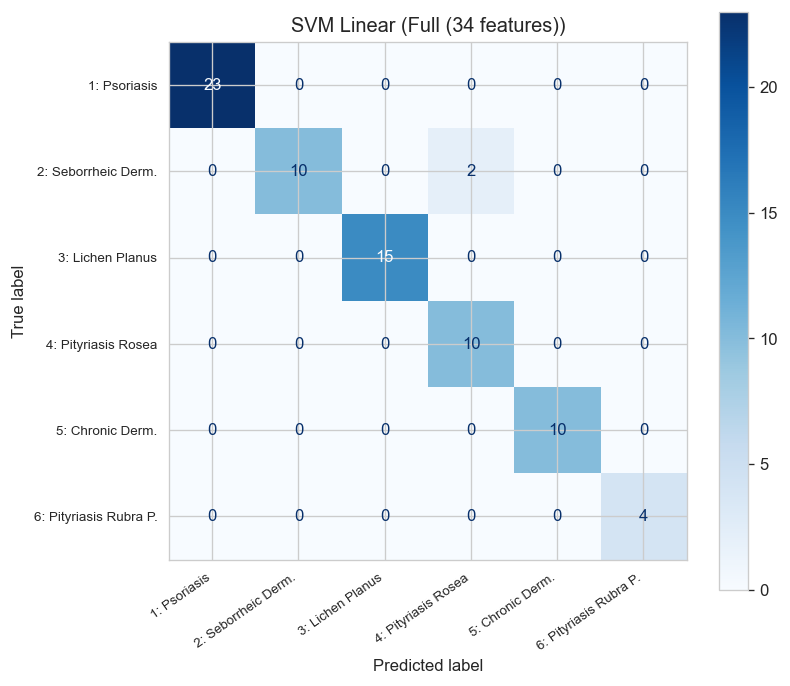

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [26]:
svm_linear_params = {"C": [0.01, 0.1, 1, 10, 100]}

train_and_evaluate(
    "SVM Linear", SVC(kernel="linear"), svm_linear_params,
    X_train_scaled, X_test_scaled, y_train, y_test,
    feature_set_label="Full (34 features)",
)


  SVM Linear (PCA-reduced)
  Best parameters : {'C': 0.01}
  CV accuracy     : 0.9760
  Test accuracy   : 0.9730

                        precision    recall  f1-score   support

          1: Psoriasis       1.00      1.00      1.00        23
   2: Seborrheic Derm.       1.00      0.83      0.91        12
      3: Lichen Planus       1.00      1.00      1.00        15
   4: Pityriasis Rosea       0.83      1.00      0.91        10
      5: Chronic Derm.       1.00      1.00      1.00        10
6: Pityriasis Rubra P.       1.00      1.00      1.00         4

              accuracy                           0.97        74
             macro avg       0.97      0.97      0.97        74
          weighted avg       0.98      0.97      0.97        74



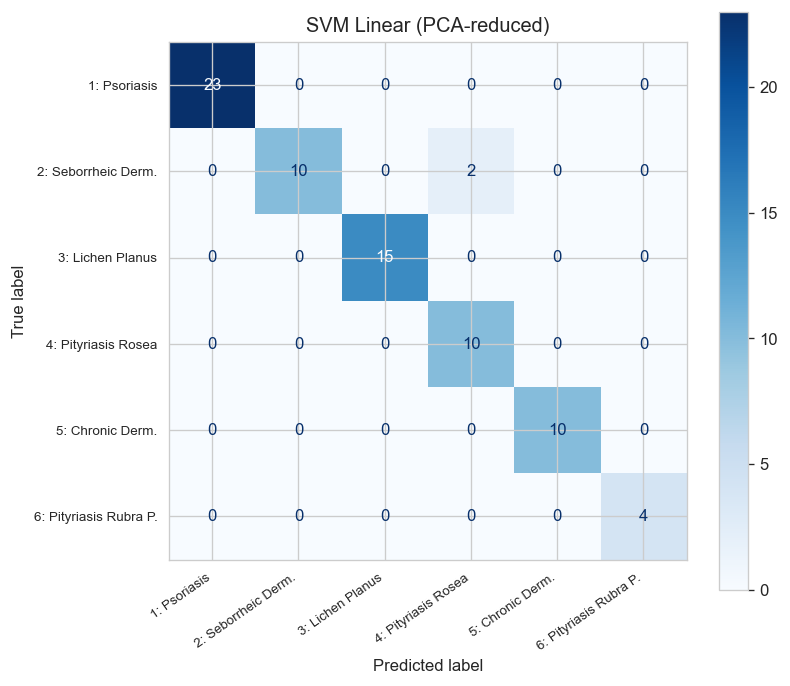

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.01
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
train_and_evaluate(
    "SVM Linear", SVC(kernel="linear"), svm_linear_params,
    X_train_pca, X_test_pca, y_train, y_test,
    feature_set_label="PCA-reduced",
)

### 4.2 SVM — RBF Kernel

Now I try the RBF (Gaussian) kernel, which can capture non-linear boundaries.
Here I tune both `C` and `gamma`.


  SVM RBF (Full (34 features))
  Best parameters : {'C': 1, 'gamma': 'scale'}
  CV accuracy     : 0.9794
  Test accuracy   : 0.9730

                        precision    recall  f1-score   support

          1: Psoriasis       1.00      1.00      1.00        23
   2: Seborrheic Derm.       1.00      0.83      0.91        12
      3: Lichen Planus       1.00      1.00      1.00        15
   4: Pityriasis Rosea       0.83      1.00      0.91        10
      5: Chronic Derm.       1.00      1.00      1.00        10
6: Pityriasis Rubra P.       1.00      1.00      1.00         4

              accuracy                           0.97        74
             macro avg       0.97      0.97      0.97        74
          weighted avg       0.98      0.97      0.97        74



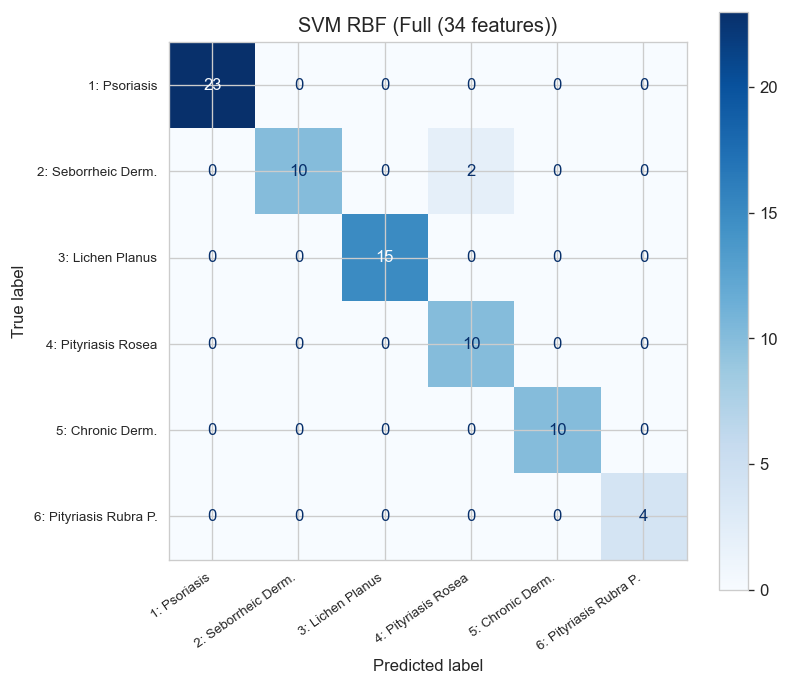

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
svm_rbf_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
}

train_and_evaluate(
    "SVM RBF", SVC(kernel="rbf"), svm_rbf_params,
    X_train_scaled, X_test_scaled, y_train, y_test,
    feature_set_label="Full (34 features)",
)


  SVM RBF (PCA-reduced)
  Best parameters : {'C': 1, 'gamma': 'scale'}
  CV accuracy     : 0.9794
  Test accuracy   : 0.9730

                        precision    recall  f1-score   support

          1: Psoriasis       1.00      1.00      1.00        23
   2: Seborrheic Derm.       1.00      0.83      0.91        12
      3: Lichen Planus       1.00      1.00      1.00        15
   4: Pityriasis Rosea       0.83      1.00      0.91        10
      5: Chronic Derm.       1.00      1.00      1.00        10
6: Pityriasis Rubra P.       1.00      1.00      1.00         4

              accuracy                           0.97        74
             macro avg       0.97      0.97      0.97        74
          weighted avg       0.98      0.97      0.97        74



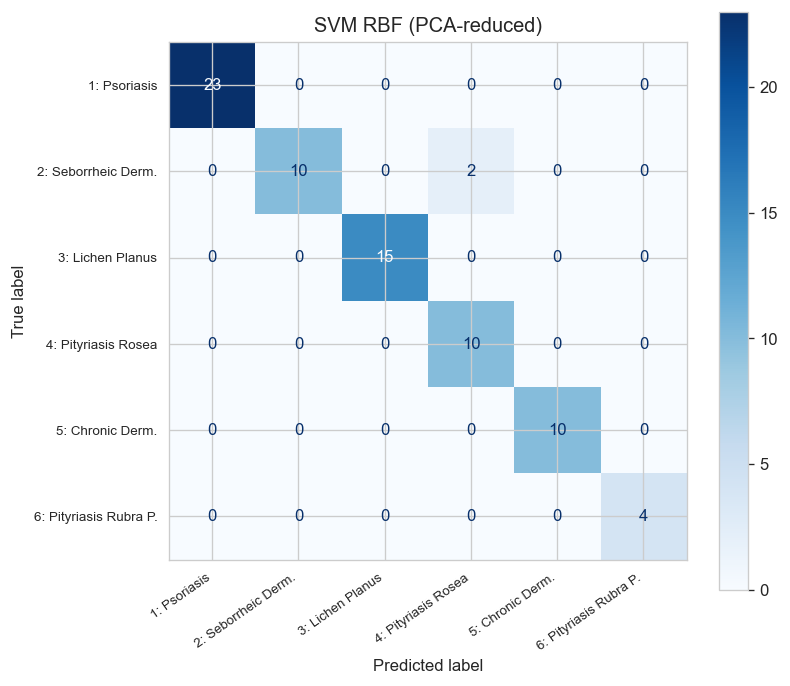

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:
train_and_evaluate(
    "SVM RBF", SVC(kernel="rbf"), svm_rbf_params,
    X_train_pca, X_test_pca, y_train, y_test,
    feature_set_label="PCA-reduced",
)

### 4.3 Random Forest

Finally, I try Random Forest — an ensemble of decision trees. I tune the number
of trees, maximum depth, and minimum samples per split.


  Random Forest (Full (34 features))
  Best parameters : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  CV accuracy     : 0.9828
  Test accuracy   : 0.9595

                        precision    recall  f1-score   support

          1: Psoriasis       1.00      1.00      1.00        23
   2: Seborrheic Derm.       0.91      0.83      0.87        12
      3: Lichen Planus       1.00      1.00      1.00        15
   4: Pityriasis Rosea       0.82      0.90      0.86        10
      5: Chronic Derm.       1.00      1.00      1.00        10
6: Pityriasis Rubra P.       1.00      1.00      1.00         4

              accuracy                           0.96        74
             macro avg       0.95      0.96      0.95        74
          weighted avg       0.96      0.96      0.96        74



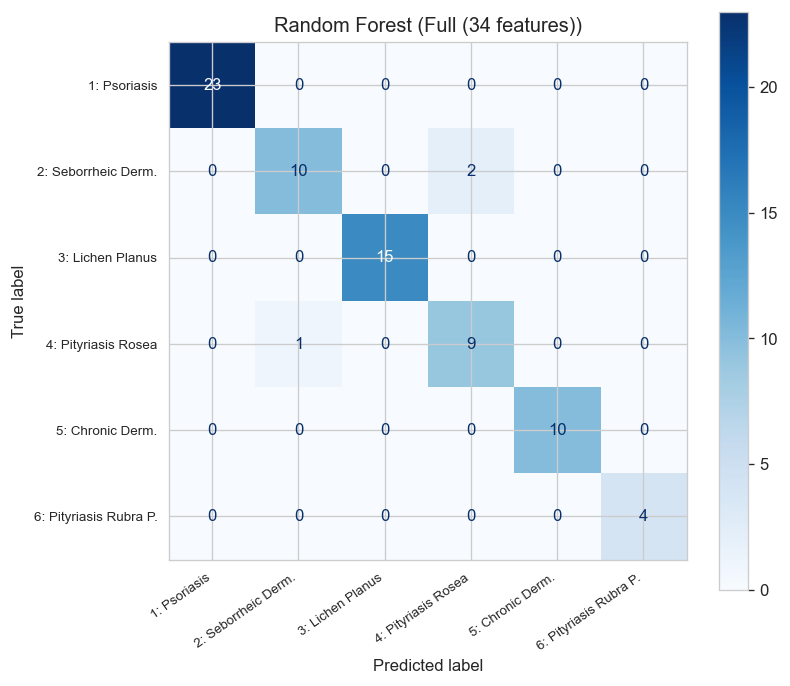

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [30]:
rf_params = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
}

train_and_evaluate(
    "Random Forest", RandomForestClassifier(random_state=42), rf_params,
    X_train_scaled, X_test_scaled, y_train, y_test,
    feature_set_label="Full (34 features)",
)


  Random Forest (PCA-reduced)
  Best parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  CV accuracy     : 0.9692
  Test accuracy   : 0.9459

                        precision    recall  f1-score   support

          1: Psoriasis       0.96      1.00      0.98        23
   2: Seborrheic Derm.       0.91      0.83      0.87        12
      3: Lichen Planus       1.00      0.93      0.97        15
   4: Pityriasis Rosea       0.82      0.90      0.86        10
      5: Chronic Derm.       1.00      1.00      1.00        10
6: Pityriasis Rubra P.       1.00      1.00      1.00         4

              accuracy                           0.95        74
             macro avg       0.95      0.94      0.95        74
          weighted avg       0.95      0.95      0.95        74



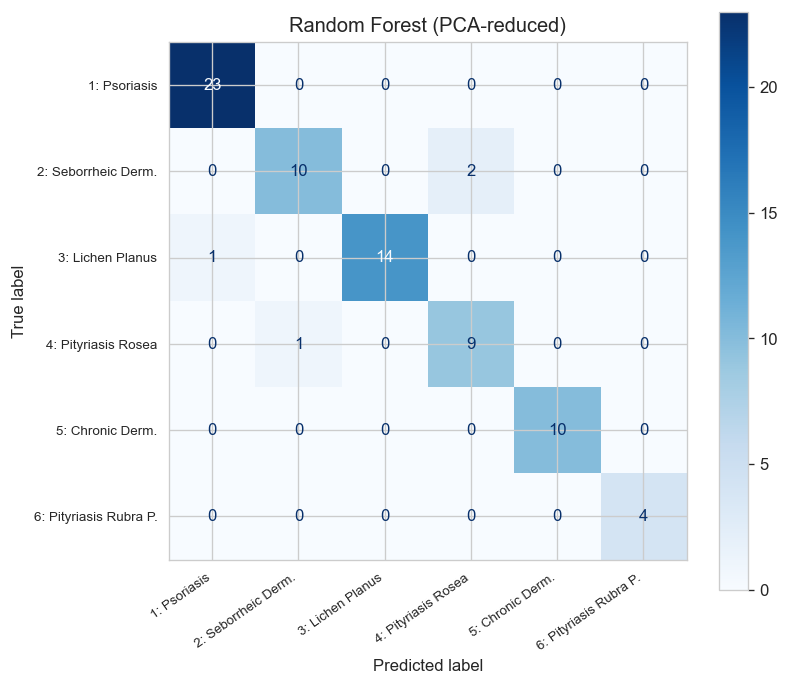

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
train_and_evaluate(
    "Random Forest", RandomForestClassifier(random_state=42), rf_params,
    X_train_pca, X_test_pca, y_train, y_test,
    feature_set_label="PCA-reduced",
)

---
## 5. Summary & Comparison

Let me put all the results into one table and a chart to make it easier to compare.

In [32]:
results_df = pd.DataFrame(results)
results_df["Test Accuracy (float)"] = results_df["Test Accuracy"].astype(float)
results_df = results_df.sort_values("Test Accuracy (float)", ascending=False)

print("\n" + "=" * 80)
print("  RESULTS SUMMARY")
print("=" * 80)
display(results_df[["Model", "Features", "Best Params", "CV Accuracy", "Test Accuracy"]])


  RESULTS SUMMARY


,Model,Features,Best Params,CV Accuracy,Test Accuracy
0,SVM Linear,Full (34 features),{'C': 0.1},0.9794,0.9730
1,SVM Linear,PCA-reduced,{'C': 0.01},0.9760,0.9730
2,SVM RBF,Full (34 features),"{'C': 1, 'gamma': 'scale'}",0.9794,0.9730
3,SVM RBF,PCA-reduced,"{'C': 1, 'gamma': 'scale'}",0.9794,0.9730
4,Random Forest,Full (34 features),"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.9828,0.9595
5,Random Forest,PCA-reduced,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.9692,0.9459


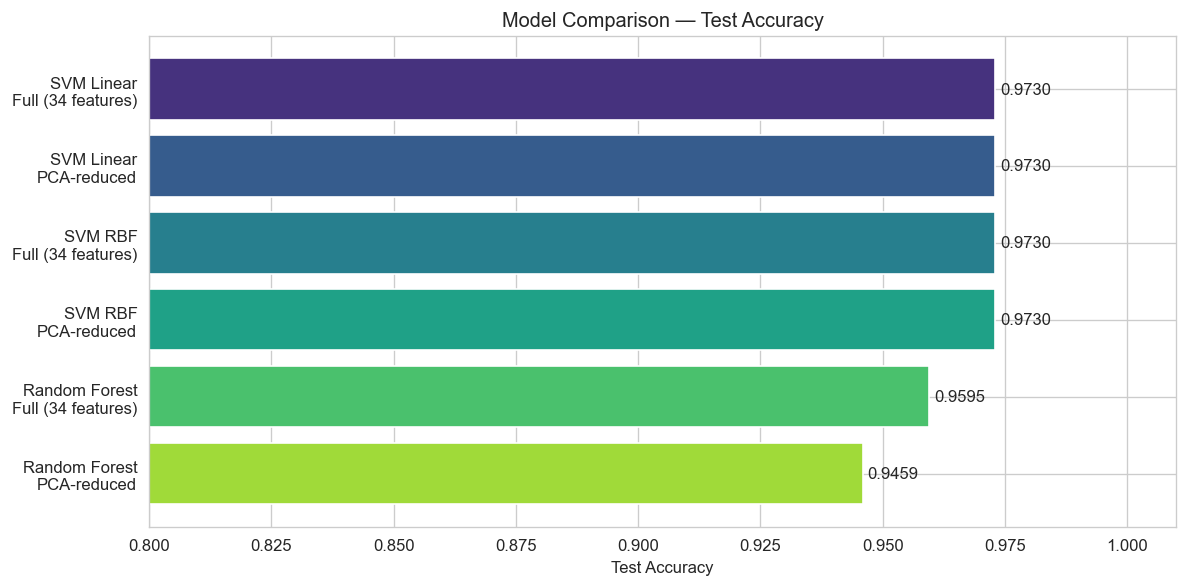

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = results_df["Model"] + "\n" + results_df["Features"]
colors = sns.color_palette("viridis", len(results_df))
bars = ax.barh(labels, results_df["Test Accuracy (float)"], color=colors)
ax.set_xlabel("Test Accuracy")
ax.set_title("Model Comparison — Test Accuracy")
ax.set_xlim(0.80, 1.01)
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 6. Conclusions

### What I did

I worked with the UCI Dermatology dataset (366 samples, 34 features, 6 classes) and
tried to classify six types of erythemato-squamous skin diseases. I preprocessed the
data by imputing the 8 missing age values with **KNN imputation** (k=5), which is
better than just plugging in the median because it takes into account the patient's
other features when estimating the missing age. Then I standardized all features and
split the data 80/20 with stratification.

I trained three classifiers — **SVM Linear**, **SVM RBF**, and **Random Forest** — each
tuned via **GridSearchCV** (5-fold stratified CV). I also applied **PCA** to reduce
dimensionality and ran all three models again on the PCA-transformed features to see
if it helps.

### Results

| Model | Features | Best Params | CV Accuracy | Test Accuracy |
|-------|----------|-------------|-------------|---------------|
| SVM Linear | Full (34) | C=0.1 | 97.94% | **97.30%** |
| SVM Linear | PCA | C=0.01 | 97.60% | **97.30%** |
| SVM RBF | Full (34) | C=1, gamma=scale | 97.94% | **97.30%** |
| SVM RBF | PCA | C=1, gamma=scale | 97.94% | **97.30%** |
| Random Forest | Full (34) | depth=10, split=2, trees=100 | 98.28% | **95.95%** |
| Random Forest | PCA | depth=None, split=2, trees=100 | 96.92% | **94.59%** |

### Which method is the best and why?

The best results came from **SVM** — both the linear and RBF kernels achieved **97.30%**
test accuracy, which is identical. I think this happened because the disease classes are
already quite well separated in the feature space once the data is scaled, so a linear
boundary is enough and the RBF kernel doesn't add anything on top of that.

Between the two, I'd pick the **linear kernel** since it gives the same accuracy but is
simpler — there's no extra `gamma` parameter to worry about, and a simpler model is
generally preferable when performance is equal (Occam's razor).

**Random Forest** scored a bit lower (95.95%). What's interesting is that its CV accuracy
was actually the highest at 98.28%, but then it dropped to 95.95% on the test set — a
gap of about 2.3%. This tells me it was overfitting a little. Decision trees split on
individual features (axis-aligned boundaries), so if the real class boundary runs
diagonally across several features, a tree needs many splits to approximate it, whereas
SVM finds that boundary directly.

### Effect of PCA

For SVM, PCA made **no difference** — accuracy stayed at 97.30%. This means the important
information is in the high-variance components and the low-variance ones that PCA drops
are just noise. So in principle, I could use PCA to speed things up without losing anything,
though with only 34 features speed isn't really a concern.

For Random Forest, PCA actually **hurt** — accuracy dropped from 95.95% to 94.59%. I think
this is because PCA creates linear combinations of features, and decision trees can only
split on one feature at a time. When features are already meaningful individual measurements
(like "scaling" or "itching"), trees can use them directly. But PCA components like
"0.3×scaling + 0.5×itching − 0.2×age" are harder to work with for a tree.

**Bottom line:** PCA is useful when you have hundreds or thousands of features, but for
this 34-feature dataset it's not needed and can even be counterproductive for tree-based
models.

### Comparison with the state of the art

This dataset has been around since the late 1990s and many papers have used it. Here's
what I found in the literature:

| Method | Reported Accuracy |
|--------|-------------------|
| Neural Networks (ANN) | ~98.3% |
| Ensemble meta-techniques | ~97.8% |
| Feature selection + SVM/KNN hybrids | 96–98% |

My best result of **97.30%** falls right within this range. The dataset is small (366
samples), so a different random train/test split could easily shift the result by 1–2%
in either direction. To get closer to 98%+ I'd probably need to either use 10-fold CV
for the final evaluation (rather than a single split), try more advanced feature selection,
or use a neural network. But for a straightforward sklearn pipeline, I'm happy with 97.30%.

### What I learned

1. **SVM Linear is the winner** — simple, fast, and 97.30% accurate. When the data is
   well-structured with good features, you don't always need fancy non-linear models.
2. **GridSearchCV matters a lot** — without tuning, default SVM with C=1 or Random Forest
   with unlimited depth would give noticeably different results.
3. **KNN imputation** is a better approach to missing values than just using the median,
   because it considers the patient's other attributes.
4. **PCA is not always helpful** — it didn't change SVM results and made Random Forest worse.
   It's a tool that should be applied thoughtfully, not blindly.
5. My results **match the state of the art** for this dataset, which confirms that the
   approach is sound.